# 02 · IDEAgent — Agentic Quality-Diversity Search for Research Idea Generation

**Paper:** Gumma, Majumder, Sinhahajari, Poria (NTU DeCLaRe). arXiv 2607.22375 (`papers/2607.22375v1.pdf`).

**Code status:** the authors' repository (`github.com/declare-lab/IDEAgent`, commit `1213761`) is a faithful Python implementation and ships the 32-topic background corpus. This notebook **drives the vendored repo directly** (`notebooks/vendor/IDEAgent`, gitignored; re-fetched by the setup cell) after a small patch (`notebooks/patches/ideagent_openrouter.patch`) that (a) removes a stray constructor kwarg that crashes the shipped runner, (b) adds `base_url` support so every role can run through OpenRouter, and (c) controls hidden reasoning on reasoning models so long outputs are not truncated. Two things the paper defines but the repo does not ship — **Yield (Alg. 2)** and **greedy max–min topic selection (Alg. 1)** — are implemented in `notebooks/ideagent_extras.py` on top of the repo's exact maximum-clique routine.

All roles use the project's OpenRouter model (`.env`). The paper used gpt-5.6 / gemini-3.x, so absolute scores differ; the mechanisms are what is under test.

| § | Building block | Paper ref | Repo code |
|---|---|---|---|
| 1 | Background corpus X and topic context | Sec. 3.1, 4 | `ideagent/data.py` |
| 2 | Ideator | Sec. 3.2 | `agents.IdeatorAgent.open` |
| 3 | Stenographer σ(I) = (p, m, v, a, e) | eq. (1) | `signature.extract_signature` |
| 4 | Quality Evaluator NB / C / F (0–100) | Sec. 3.2 | `agents.QualityAgent.evaluate` |
| 5 | Soundness Panel M samples, severe/disputed/invalid | eq. (2) | `agents.evaluate_soundness_multi`, `generation_loop._soundness_panel_status` |
| 6 | Diversity Judge D_I + duplicate list | Sec. 3.2 | `diversity_judge.judge_diversity` |
| 7 | Stores A/Q/H/R, gate G (eq. 4), routing cases 1–4 | Sec. 3.3 Stage II | `archive.Archive.consider`, `Thresholds` |
| 8 | Q_b = 0.7N + 0.2S + 0.1C, archive replacement | eq. (5) | `archive.Candidate.outranks` |
| 9 | Critic → repair | Stage II | `agents.CriticAgent.focused_review`, `prompts.op_critic_revision` |
| 10 | Refinement + blinded position-swapped comparison | Stage III | `GenerationLoop._relative_nb_comparison`, `Archive.consider_accepted_refinement` |
| 11 | Yield (max clique), successful topics, CST | Alg. 2, eq. (7) | `ideagent_extras.yield_count` (+ repo `_maximum_clique`) |
| 12 | Greedy max–min topic selection | Alg. 1 | `ideagent_extras.greedy_maxmin_topics` |
| 13 | Mini end-to-end run vs Stateless baseline, evaluated with the paper's protocol | Sec. 5–6 | `GenerationLoop.run_topic`, `quality_eval`, `diversity_eval` |

In [1]:
import os, sys, json, time, dataclasses, hashlib
os.environ.setdefault("TQDM_DISABLE", "1")   # the repo's evaluators print tqdm bars; keep the notebook readable
sys.path.insert(0, os.path.abspath("."))
import common
from common import md, show_source, df, QUICK, USAGE, OUTPUT_DIR
import matplotlib.pyplot as plt
import numpy as np
common.banner()
# --- vendor + patch the authors' repo at the pinned commit
VENDOR = common.ensure_repo("https://github.com/declare-lab/IDEAgent", "121376126a4864ee5436ea5a23ffc8dc0f7842c5", "IDEAgent")
applied = common.apply_patch("patches/ideagent_openrouter.patch", VENDOR)
print("vendored at", VENDOR, "| patch applied now:", applied)
sys.path.insert(0, str(VENDOR))
import ideagent_extras as X
from ideagent.data import load_raw_topic_groups, parse_paper, build_background_context, truncate_by_tokens_rough
from ideagent.agents import IdeatorAgent, CriticAgent, QualityAgent, evaluate_soundness_multi
from ideagent.signature import extract_signature, SIGNATURE_FIELDS, SemanticSignature
from ideagent.diversity_judge import judge_diversity, DiversityVerdict
from ideagent.archive import Archive, Thresholds, Candidate, EARLY_WEIGHTS, LATE_WEIGHTS, ACCEPTED, REPLACED, QUALIFIED_RETIRED, KEEP_ACCEPTED, REJECT_DUPLICATE, REPAIR_QUEUED, REPAIR_RETAINED, REJECT_UNSOUND, REJECT_EVAL_FAIL
from ideagent.generation_loop import Config, GenerationLoop, _soundness_panel_status, _score_map
from ideagent.prompts import op_free, op_critic_revision, build_repair_critic_user, REPAIR_CRITIC_SYSTEM, RELATIVE_NB_SYSTEM
OUT = OUTPUT_DIR / "ideagent"; OUT.mkdir(exist_ok=True)

Model: `deepseek/deepseek-v4-flash` via `https://openrouter.ai/api/v1` · QUICK mode: `False` · outputs → `notebooks/outputs`

vendored at /mnt/berstorage/RCP/rcp-platform/notebooks/vendor/IDEAgent | patch applied now: False


## 1 · Background corpus X and topic context (Sec. 3.1, Sec. 4)

Each topic is a set of 5–8 background papers (title, abstract, introduction, conclusion) that "could have influenced" several published papers. The Ideator only ever sees this closed corpus. We use one shipped topic throughout.

In [2]:
TOPICS = load_raw_topic_groups(str(VENDOR / "data" / "bkgd_papers.jsonl"))
print(len(TOPICS), "topics;", sorted({t["domain_id"] for t in TOPICS}))
display(df([{"topic_id": t["topic_id"], "domain": t["domain_id"], "name": t.get("topic_name", ""), "#background": len(t["background_papers"]), "#target": len(t["target_papers"])} for t in TOPICS]).head(12))
TOPIC = TOPICS[1]
papers = [parse_paper(p) for p in TOPIC["background_papers"]]
BACKGROUND = truncate_by_tokens_rough(build_background_context(papers), 12000)
print(f"\nTopic {TOPIC['topic_id']} — {TOPIC.get('topic_name','')}: {len(papers)} papers, context ≈ {len(BACKGROUND.split())} words")
print(BACKGROUND[:700], "...")

32 topics; ['cs.AI', 'cs.CL', 'cs.CV', 'cs.DC', 'cs.IR', 'cs.LG', 'cs.RO', 'cs.SE']


,topic_id,domain,name,#background,#target
0,cs.AI-001,cs.AI,Scaling LLM Reasoning via Reinforcement Learning,8,5
1,cs.AI-002,cs.AI,Scaling LLM Reasoning via Reinforcement Learning,8,5
2,cs.AI-003,cs.AI,Reasoning in Large Language Models,5,3
3,cs.AI-004,cs.AI,Reinforcement Learning for Advanced AI Reasoning,6,3
4,cs.CL-012,cs.CL,Deep Learning Representation and Analysis,8,3
5,cs.CL-026,cs.CL,Scaling Laws for Neural Networks,8,4
6,cs.CL-034,cs.CL,Knowledge Localization and Model Editing,7,3
7,cs.CL-036,cs.CL,Efficient Attention Mechanisms and KV Cache Op...,8,3
8,cs.CL-040,cs.CL,Multilingual Multitask Language Understanding ...,6,3
9,cs.CL-047,cs.CL,Adversarial Robustness of LLM Safety Alignment,6,3



Topic cs.AI-002 — Scaling LLM Reasoning via Reinforcement Learning: 8 papers, context ≈ 7709 words
<BACKGROUND>
[Paper 1]
Paper ID: 2402.03300
Title: DeepSeekMath: Pushing the Limits of Mathematical Reasoning in Open Language Models
Text:
Title: DeepSeekMath: Pushing the Limits of Mathematical Reasoning in Open Language Models

Abstract: Mathematical reasoning poses a significant challenge for language models due to its complex and structured nature. In this paper, we introduce DeepSeekMath 7B, which continues pre-training DeepSeek-Coder-Base-v1.5 7B with 120B math-related tokens sourced from Common Crawl, together with natural language and code data. DeepSeekMath 7B has achieved an impressive score of 51.7% on the competition-level MATH benchmark without relying on external toolkits and  ...


### Build the agents (one OpenRouter client per role, as in `scripts/run_ideagent.py`)

The repo builds five role clients (`ideator`, `critic`, `quality`, `steno`, `judge`) from the YAML; here they all point at `RCP_MODEL`. The `GenerationLoop` object holds them and is reused by every section, so §13 runs the *same* agents end to end.

In [3]:
ic, ikw = X.make_client(max_new_tokens=6000, tag="ideator")
cc, ckw = X.make_client(max_new_tokens=3000, tag="critic")
qc, qkw = X.make_client(max_new_tokens=4000, tag="quality+soundness")
sc, skw = X.make_client(max_new_tokens=1024, tag="steno")
jc, jkw = X.make_client(max_new_tokens=2048, tag="judge")
SOUND_N = 3 if QUICK else 5
cfg = Config(input_jsonl=str(VENDOR / "data/bkgd_papers.jsonl"), output_dir=str(OUT / "run"), max_budget=2 if QUICK else 3,
             soundness_n=SOUND_N, soundness_fatal_min_votes=(SOUND_N // 2) + 1, diversity_D=60, accepted_capacity=3,
             repair_capacity=1, repair_attempt_limit=1, accepted_refinement_limit=1, auxiliary_attempt_limit=1, consolidate_every=12)
T = cfg.thresholds()
loop = GenerationLoop(config=cfg, ideator=IdeatorAgent(role="ideator", client=ic, gen_kwargs=ikw), critic=CriticAgent(role="critic", client=cc, gen_kwargs=ckw),
                      quality=QualityAgent(role="quality", client=qc, gen_kwargs=qkw), steno_client=sc, steno_gen_kwargs=skw, judge_client=jc, judge_gen_kwargs=jkw)
print("thresholds:", T)
print("early / late Q_b weights:", EARLY_WEIGHTS, LATE_WEIGHTS)

thresholds: Thresholds(soundness_floor=60.0, soundness_fatal_threshold=3, soundness_fatal_min_votes=3, nb_min=60, clarity_min=60, diversity_D=60, repair_margin=20, repair_diversity_D=45)
early / late Q_b weights: QualityWeights(non_obviousness=0.7, soundness=0.2, clarity=0.1) QualityWeights(non_obviousness=0.4, soundness=0.4, clarity=0.2)


## 2 · Ideator (Sec. 3.2)

"The Ideator is the core generator agent that reads a background corpus X to generate a complete seed idea from scratch." The opening directive `op_free` asks for a novel, sound idea distinct from the archive (empty here) and from the rejected-pattern summary.

In [4]:
print(op_free([], "")[:900], "...")

Propose a NOVEL, non-obvious, and SOUND research idea for this problem space. It must not be a direct combination, extension, or ablation of the background papers. You are free to choose any problem and any mechanism (it may combine several parts of the pipeline) -- just make it genuinely distinct from what already exists.

NON-OBVIOUSNESS IS A FLOOR, NOT A BOX TO CHECK. A superficially strong score (even 80/100) does not establish that the central move is harder to anticipate than another strong idea. Identify the most obvious competent approach to the same failure mode, then make the proposed causal lever genuinely discontinuous from that approach. Extra components, implementation detail, jargon, and combinations of familiar techniques do not create non-obviousness. The conceptual leap must remain clear after all decorative details are removed, and it must remain sound rather than borr ...


In [5]:
t0 = time.time()
IDEA = loop.ideator.open(background=BACKGROUND, prior_cores_block=None, critic_opening_challenge=op_free([], ""))
print(f"{len(IDEA)} chars in {time.time()-t0:.0f}s\n")
print(IDEA[:2500], "\n...")

6509 chars in 53s

# Idea: Adversarial Reward Shaping via Self-Generated Distractors

## Motivation

The background papers reveal a consistent pattern in how reinforcement learning is applied to mathematical reasoning: reward is computed from *correctness against ground truth*, and the policy learns to produce longer chains of thought that explore multiple solution paths. The overthinking problem (Paper 2) and the GRPO bias toward lengthening incorrect responses (Paper 7) both point to a deeper issue: the reward signal treats all correct answers equivalently, regardless of *how fragile* or *brittle* the reasoning was. A model that stumbles through 10 wrong attempts before landing on the right answer receives the same reward as one that solves cleanly on the first try. This means the RL optimization has no incentive to distinguish robust reasoning from lucky guesswork wrapped in long chains-of-thought.

## Mechanism

The core idea is to introduce **adversarial distractors generated by t

## 3 · Stenographer σ(I) = (p, m, v, a, e) — eq. (1)

The Stenographer compresses a draft into a quintuple (problem, central mechanism, novel value addition, key assumptions, expected measurable effect). Each field is capped in characters; this compact form is what all later comparisons use.

In [6]:
print("fields:", SIGNATURE_FIELDS)
SIG = extract_signature(IDEA, idea_id="i1", client=sc, gen_kwargs=skw, char_cap=cfg.signature_char_cap)
for f in SIGNATURE_FIELDS: print(f"{f:>16}: {getattr(SIG, f)}")
print("\ncompact form used in prompts:\n", SIG.compact())

fields: ('problem', 'core_mechanism', 'novel_move', 'key_assumption', 'expected_effect')


         problem: RL for mathematical reasoning rewards all correct answers equally, so it fails to penalize brittle reasoning that relies on spurious correlations or lucky guesswork, leading to overthinking and fragile long chains of thought.
  core_mechanism: The model generates N mutated problem variants from its own current policy, solves them zero-shot, and the reward for the original problem is the correctness bonus on the original minus a penalty proportional to the fraction of distractors…
      novel_move: Using the model's own success rate on its self-generated adversarial variants as a secondary reward signal, rather than relying on external annotations, length penalties, or process supervision of intermediate steps.
  key_assumption: The model's own distractor generation distribution is not separately optimizable to evade the penalty — the policy cannot systematically produce trivially easy distractors without already being robust, because the same brittle representati…
 ex

## 4 · Quality Evaluator — NB, C, F on 0–100 (Sec. 3.2)

One structured call scores the rubrics; non-obviousness (NB), mechanism clarity (C) and feasibility (F) are the ones the paper uses (feasibility is *non-gating*). The parsing/tiering helpers are pure Python.

In [7]:
loop.quality.reset_for_topic(prior_final_idea_cores=[])
VQ = loop.quality.evaluate(prev_critic_turn="", latest_ideator_turn=IDEA, current_final_idea_core=None)
SCORES = _score_map(VQ.get("rubric_assessment") or [])
display(df([{"rubric": r.get("id"), "score": r.get("score"), "evidence": str(r.get("evidence", ""))[:160]} for r in VQ.get("rubric_assessment", [])]))
print({k: SCORES.get(k) for k in ("non_obviousness", "mechanism_clarity", "feasibility")}, "| primary bottleneck:", VQ.get("primary_bottleneck"))

,rubric,score,evidence
0,prior_episode_overlap,0,
1,source_boundedness/narrowness,20,The idea is motivated by multiple background p...
2,motivation_distinctness,80,The motivation targets the brittleness of reas...
3,non_obviousness,70,The idea of using self-generated distractors a...
4,feasibility,40,The idea specifies a concrete implementation (...
5,mechanism_clarity,60,The causal chain is clearly described: model g...


{'non_obviousness': 70, 'mechanism_clarity': 60, 'feasibility': 40} | primary bottleneck: non_obviousness


## 5 · Soundness Panel — eq. (2)

$$S_I=\frac{100}{9M}\sum_{j=1}^{M} S_I^{j}$$ with M independent 0–9 judgments; a judgment is **severe** if ≤ 3; one severe vote makes the idea *disputed* (repairable), a majority makes it *invalid* (discarded).

In [8]:
show_source(_soundness_panel_status)
PANEL = evaluate_soundness_multi(IDEA, client=qc, gen_kwargs=qkw, n=SOUND_N)
VOTES = [r["score"] for r in PANEL]
S100 = sum(VOTES) / len(VOTES) * 100 / 9
fatal, disputed, n_severe = _soundness_panel_status(VOTES, fatal_threshold=T.soundness_fatal_threshold, fatal_min_votes=T.soundness_fatal_min_votes)
print(f"votes={VOTES} → S_I={S100:.1f}/100 | severe votes={n_severe} | disputed={disputed} | invalid={fatal}")
for r in sorted(PANEL, key=lambda r: r["score"])[:2]: print(f"  worst rationale ({r['score']}): {r['rationale'][:300]}")

**_soundness_panel_status**

```python
def _soundness_panel_status(
    samples: list[int], *, fatal_threshold: int, fatal_min_votes: int,
) -> tuple[bool, bool, int]:
    """Return (hard_fatal, disputed, severe_vote_count).

    A partial/empty panel still fails closed through eval_ok; an empty panel is also marked fatal.
    A non-consensus severe objection is preserved as a repairable dispute rather than ignored or
    allowed directly through the acceptance gate.
    """

    if not samples:
        return True, False, 0
    votes = sum(score <= fatal_threshold for score in samples)
    return votes >= fatal_min_votes, 0 < votes < fatal_min_votes, votes

```

votes=[7, 6, 6, 3, 6] → S_I=62.2/100 | severe votes=1 | disputed=True | invalid=False
  worst rationale (3): The core causal claim relies on the assumption that a brittle model cannot control the difficulty of its self-generated distractors, but this ignores the possibility of reward hacking: the model could learn to generate distractors that are trivially different in ways it can solve (e.g., changing a n
  worst rationale (6): The core logic is sound: a model that genuinely understands the reasoning would generate distractors that test the same underlying skills and solve them, while a model relying on spurious correlations would generate distractors that expose its brittleness, creating an honest signal. The degenerate c


In [9]:
md("**Boundary behaviour of the panel rule** (pure Python on hand-built vote vectors, M=5, severe ≤ 3, invalid at ≥ 3 votes):")
rows = []
for votes in ([7, 8, 6, 7, 9], [7, 8, 3, 7, 9], [3, 8, 2, 7, 9], [3, 3, 2, 7, 9], [3, 3, 3, 3, 3], []):
    f, d, n = _soundness_panel_status(votes, fatal_threshold=3, fatal_min_votes=3)
    rows.append({"votes": votes, "S_I (0-100)": round(sum(votes) / len(votes) * 100 / 9, 1) if votes else None, "severe": n, "disputed": d, "invalid": f})
display(df(rows))

**Boundary behaviour of the panel rule** (pure Python on hand-built vote vectors, M=5, severe ≤ 3, invalid at ≥ 3 votes):

,votes,S_I (0-100),severe,disputed,invalid
0,"[7, 8, 6, 7, 9]",82.2,0,False,False
1,"[7, 8, 3, 7, 9]",75.6,1,True,False
2,"[3, 8, 2, 7, 9]",64.4,2,True,False
3,"[3, 3, 2, 7, 9]",53.3,3,False,True
4,"[3, 3, 3, 3, 3]",33.3,5,False,True
5,[],NaN,0,False,True


## 6 · Diversity Judge (Sec. 3.2)

Compares the candidate's signature against the **active** archive A and the **historical** archive H (and the rejected-pattern summary R) and returns D_I ∈ [0, 100] plus explicit duplicate lists. With an empty archive the repo short-circuits to D = 100 without a call, so we first seed a small archive with two more Ideator drafts.

In [10]:
extra = []
for i in range(2):
    txt = loop.ideator.open(background=BACKGROUND, prior_cores_block=None, critic_opening_challenge=op_free([SIG] + [s for _, s in extra], ""))
    extra.append((txt, extract_signature(txt, idea_id=f"i{i+2}", client=sc, gen_kwargs=skw)))
    print(f"i{i+2}: {extra[-1][1].core_mechanism[:150]}")
accepted_sigs = [s for _, s in extra]
V_new = judge_diversity(SIG, accepted=accepted_sigs, historical=[], rejected_summary="", historical_field_char_cap=120, client=jc, gen_kwargs=jkw)
print("\ncandidate i1 vs archive {i2,i3}:", V_new)
# a near-duplicate: re-judge i2's own signature under a new id against an archive containing i2
dup = dataclasses.replace(accepted_sigs[0], id="i2-copy")
V_dup = judge_diversity(dup, accepted=accepted_sigs, historical=[], rejected_summary="", historical_field_char_cap=120, client=jc, gen_kwargs=jkw)
print("copy of i2 vs archive {i2,i3}:", V_dup, "→ is_duplicate =", V_dup.is_duplicate)

i2: Reward each response as (binary answer correctness) × (fraction of parsed internal reasoning chains that converge to the correct answer), computed fro


i3: Multiply the standard answer correctness reward for a problem by the average correctness of the model's zero-shot solutions to k (5-10) automatically 



candidate i1 vs archive {i2,i3}: DiversityVerdict(parsed=True, diversity_score=75, duplicate_ids=[], historical_duplicate_ids=[], matches_rejected_family=False, rejected_family='none', closest=[{'id': 'i2', 'same_mechanism': False, 'same_problem': True, 'substantive_difference': True}, {'id': 'i3', 'same_mechanism': False, 'same_problem': True, 'substantive_difference': True}])


copy of i2 vs archive {i2,i3}: DiversityVerdict(parsed=True, diversity_score=0, duplicate_ids=['i2'], historical_duplicate_ids=[], matches_rejected_family=False, rejected_family='', closest=[{'id': 'i2', 'same_mechanism': True, 'same_problem': True, 'substantive_difference': False}, {'id': 'i3', 'same_mechanism': False, 'same_problem': True, 'substantive_difference': True}]) → is_duplicate = True


## 7 · Stores A/Q/H/R, the qualification gate G (eq. 4) and Stage II routing

$$G(I)=\mathbb 1\big[(N_I\ge\tau_N \wedge S_I\ge\tau_S \wedge C_I\ge\tau_C)\wedge\neg\text{invalid}(I)\wedge\neg\text{disputed}(I)\big],\quad \tau=60$$

`Archive.consider` implements the four routing cases: (1) purely-historical or multi-active duplicate → reject; (2) exactly one active duplicate → replace if higher Q_b else reject; (3) not distinct enough (D < τ_D) → reject; (4) passes G and D ≥ τ_D → accept; within δ = 20 of the thresholds and not invalid → one repair opportunity. First the real candidate (assembled by the repo's own `_evaluate`, which runs §3–§5 together), then edited copies to hit every branch.

In [11]:
show_source(Candidate.passes_all); show_source(Candidate.near_thresholds)
CAND = loop._evaluate(IDEA, idea_id="i1", gen=1, operator="free", topic_id=TOPIC["topic_id"], background=BACKGROUND)
print(f"assembled Candidate: NB={CAND.non_obviousness} S={CAND.soundness_100:.1f} C={CAND.mechanism_clarity} F={CAND.feasibility} votes={CAND.soundness_samples} disputed={CAND.soundness_disputed} invalid={CAND.soundness_fatal} eval_ok={CAND.eval_ok}")
print("passes G:", CAND.passes_all(T), "| near thresholds (repair-eligible):", CAND.near_thresholds(T), "| defects:", CAND.defect_text(T) or "none")

**Candidate.passes_all**

```python
    def passes_all(self, t: Thresholds) -> bool:
        return self.passes_soundness(t) and self.passes_quality(t)

```

**Candidate.near_thresholds**

```python
    def near_thresholds(self, t: Thresholds) -> bool:
        # Any non-consensus severe objection deserves its immediate bounded repair chain,
        # even when the panel mean is farther than the ordinary numeric margin.
        sound_near = (
            self.soundness_disputed
            or self.soundness_100 >= t.soundness_floor - t.repair_margin
        )
        quality_near = (
            self.non_obviousness >= t.nb_min - t.repair_margin
            and self.mechanism_clarity >= t.clarity_min - t.repair_margin
        )
        return not self.passes_all(t) and not self.soundness_fatal and sound_near and quality_near

```

assembled Candidate: NB=75 S=42.2 C=60 F=50 votes=[2, 6, 7, 2, 2] disputed=False invalid=True eval_ok=True
passes G: False | near thresholds (repair-eligible): False | defects: soundness fatal-panel consensus (3/5 votes <= 3): The core causal claim — that a model's failure on its own generated distractors indicates brittle reasoning — holds if the distractor generation process faithfully samples from the model's learned distribution. However, the mechanism overlooks a plausible degenerate case where the model learns to generate distractors that are all trivially different in a way that does not exercise the same reasoning skill, which the model can then solve correctly, avoiding the penalty without improving robustness. The argument that a brittle model cannot control this ignores that the model could learn to output simple, irrelevant variants that bypass the intended signal, violating the 'why it does not degenerate' reasoning.


In [12]:
ARCH = Archive(accepted_capacity=cfg.accepted_capacity, repair_capacity=1, repair_attempt_limit=1, accepted_refinement_limit=1)
V = loop._judge(CAND, ARCH, topic_id=TOPIC["topic_id"])
outcome = ARCH.consider(CAND, V, T, EARLY_WEIGHTS)
print("real candidate →", outcome, "| A:", list(ARCH.accepted), "| Q:", [c.id for c in ARCH.repair_archive], "| H:", len(ARCH._historical_signatures), "| R pending:", len(ARCH.rejected_pending))

real candidate → reject_unsound | A: [] | Q: [] | H: 0 | R pending: 1


In [13]:
def edited(cid, **kw):
    c = dataclasses.replace(CAND, id=cid, lineage_id=cid, **kw)
    return c
ok = DiversityVerdict(parsed=True, diversity_score=90)
rows = []
def route(label, cand, verdict, arch=None):
    a = arch or Archive(accepted_capacity=3, repair_capacity=1, repair_attempt_limit=1)
    out = a.consider(cand, verdict, T, EARLY_WEIGHTS)
    rows.append({"case": label, "NB": cand.non_obviousness, "S": round(cand.soundness_100), "C": cand.mechanism_clarity, "disputed": cand.soundness_disputed, "invalid": cand.soundness_fatal, "D": verdict.diversity_score, "dups": verdict.duplicate_ids, "→ outcome": out, "|A|": len(a.accepted), "|Q|": len(a.repair_archive)})
    return a
route("passes G, distinct (case 4)", edited("a", non_obviousness=75, soundness_100=70, mechanism_clarity=70, soundness_fatal=False, soundness_disputed=False, soundness_samples=[6, 7, 6]), ok)
route("near-miss NB 50 (repair, δ=20)", edited("b", non_obviousness=50, soundness_100=70, mechanism_clarity=70, soundness_fatal=False, soundness_disputed=False), ok)
route("far miss NB 30 (reject)", edited("c", non_obviousness=30, soundness_100=70, mechanism_clarity=70, soundness_fatal=False, soundness_disputed=False), ok)
route("disputed (1 severe) → repairable", edited("d", non_obviousness=75, soundness_100=66, mechanism_clarity=70, soundness_fatal=False, soundness_disputed=True, soundness_fatal_votes=1), ok)
route("invalid (majority severe)", edited("e", non_obviousness=75, soundness_100=40, mechanism_clarity=70, soundness_fatal=True, soundness_disputed=False, soundness_fatal_votes=3), ok)
route("passes G but D=40 < τ_D (case 3)", edited("f", non_obviousness=75, soundness_100=70, mechanism_clarity=70, soundness_fatal=False, soundness_disputed=False), DiversityVerdict(parsed=True, diversity_score=40))
a2 = route("first accept", edited("g", non_obviousness=70, soundness_100=70, mechanism_clarity=70, soundness_fatal=False, soundness_disputed=False), ok)
route("dup of g with higher Q_b (case 2 → replace)", edited("h", non_obviousness=85, soundness_100=75, mechanism_clarity=75, soundness_fatal=False, soundness_disputed=False), DiversityVerdict(parsed=True, diversity_score=20, duplicate_ids=["g"]), a2)
route("dup of h with lower Q_b (case 2 → reject)", edited("i", non_obviousness=65, soundness_100=70, mechanism_clarity=70, soundness_fatal=False, soundness_disputed=False), DiversityVerdict(parsed=True, diversity_score=20, duplicate_ids=["h"]), a2)
route("evaluator parse failure (fail closed)", edited("j", eval_ok=False), ok)
display(df(rows))

,case,NB,S,C,disputed,invalid,D,dups,→ outcome,|A|,|Q|
0,"passes G, distinct (case 4)",75,70,70,False,False,90,[],accepted,1,0
1,"near-miss NB 50 (repair, δ=20)",50,70,70,False,False,90,[],repair_queued,0,1
2,far miss NB 30 (reject),30,70,70,False,False,90,[],reject_unsound,0,0
3,disputed (1 severe) → repairable,75,66,70,True,False,90,[],repair_queued,0,1
4,invalid (majority severe),75,40,70,False,True,90,[],reject_unsound,0,0
5,passes G but D=40 < τ_D (case 3),75,70,70,False,False,40,[],reject_duplicate,0,0
6,first accept,70,70,70,False,False,90,[],accepted,1,0
7,dup of g with higher Q_b (case 2 → replace),85,75,75,False,False,20,[g],replaced,1,0
8,dup of h with lower Q_b (case 2 → reject),65,70,70,False,False,20,[h],reject_duplicate,1,0
9,evaluator parse failure (fail closed),75,42,60,False,True,90,[],reject_eval_fail,0,0


## 8 · Q_b = 0.7N + 0.2S + 0.1C and archive replacement — eq. (5)

Qualified candidates compete by the weighted score (novelty-heavy early in the search, the repo switches to 0.4/0.4/0.2 for the second half of the budget); ties break on feasibility. When A is full, a newcomer replaces the weakest member only if its Q_b is higher; the displaced idea is saved in H (it already counted toward Yield).

In [14]:
show_source(Candidate.weighted_quality); show_source(Candidate.outranks)
full = Archive(accepted_capacity=2, repair_capacity=1)
for cid, nb, s, c in [("p", 70, 70, 70), ("q", 65, 80, 75)]:
    full.consider(edited(cid, non_obviousness=nb, soundness_100=s, mechanism_clarity=c, soundness_fatal=False, soundness_disputed=False), ok, T, EARLY_WEIGHTS)
print("Q_b:", {k: round(v.weighted_quality(EARLY_WEIGHTS), 1) for k, v in full.accepted.items()}, "(capacity 2, full)")
for cid, nb, s, c in [("r", 90, 65, 65), ("s", 60, 90, 90)]:
    cand = edited(cid, non_obviousness=nb, soundness_100=s, mechanism_clarity=c, soundness_fatal=False, soundness_disputed=False)
    out = full.consider(cand, ok, T, EARLY_WEIGHTS)
    print(f"newcomer {cid} Q_b={cand.weighted_quality(EARLY_WEIGHTS):.1f} → {out}; A={list(full.accepted)}; H={list(full._historical_signatures)}; qualified lineages counted={len(full.qualified_lineages)}")

**Candidate.weighted_quality**

```python
    def weighted_quality(self, weights: QualityWeights) -> float:
        return (
            weights.non_obviousness * self.non_obviousness
            + weights.soundness * self.soundness_100
            + weights.clarity * self.mechanism_clarity
        )

```

**Candidate.outranks**

```python
    def outranks(self, other: "Candidate", weights: QualityWeights) -> bool:
        """Core Q decides; feasibility breaks only an exact floating-point tie."""
        own_q = self.weighted_quality(weights)
        other_q = other.weighted_quality(weights)
        if not isclose(own_q, other_q, rel_tol=0.0, abs_tol=1e-9):
            return own_q > other_q
        return self.feasibility > other.feasibility

```

Q_b: {'p': 70.0, 'q': 69.0} (capacity 2, full)
newcomer r Q_b=82.5 → replaced; A=['p', 'r']; H=['q']; qualified lineages counted=3
newcomer s Q_b=69.0 → qualified_retired; A=['p', 'r']; H=['q', 's']; qualified lineages counted=4


## 9 · Critic → repair (Stage II)

A near-miss (within δ of the thresholds, not invalid) gets **one** repair: the Critic receives the full idea, the failed rubrics, the quality evidence, soundness objections and competing mechanisms, and returns one focused challenge; the Ideator produces a corrected child *in the same lineage*; the child is re-evaluated and must pass the same gate and diversity requirements. If it fails, the seed-level representative is kept (`REPAIR_RETAINED`).

In [15]:
print(REPAIR_CRITIC_SYSTEM[:800], "...\n")
target = CAND if not CAND.passes_all(T) else edited("i1", non_obviousness=max(CAND.non_obviousness, 62), soundness_100=min(CAND.soundness_100, 55), soundness_disputed=True, soundness_fatal=False)
challenge = loop.critic.focused_review(system_prompt=REPAIR_CRITIC_SYSTEM, user_prompt=build_repair_critic_user(
    IDEA, defect=target.defect_text(T) or "soundness below floor", feedback_notes=target.feedback_notes, soundness_rationales=target.soundness_rationales, accepted=accepted_sigs))
print("CRITIC CHALLENGE:\n", challenge[:1200])

You are the repair critic in a research-ideation search. The controller only calls you for a candidate that is semantically diverse and close to passing its quality gates. Diagnose the stated defect against the COMPLETE idea. Return ONE precise, actionable challenge that the ideator can answer by revising the same core idea. Do not suggest abandoning the problem or switching mechanism families. Do not praise, summarize, score, or provide several options. When soundness is at issue, identify the exact degeneracy, circularity, missing invariant, or unjustified causal step and demand a construction-level repair. Treat a high non-obviousness score as provisional: explicitly protect the hard-to-anticipate central move from being conventionalized by the repair. ...



CRITIC CHALLENGE:
 You assert that a brittle model cannot avoid the robustness penalty because it cannot control whether its self-generated distractors are easy. This is unjustified: the model can learn to generate trivial distractors (e.g., changing “2+3” to “2+4”) that it solves correctly, thereby gaming the penalty. Your counterargument—that a model relying on shallow patterns “cannot control whether its own generated distractors are easy or hard”—is asserted without proof and contradicts basic RL dynamics. Provide an explicit invariant or architectural constraint (e.g., forcing distractors to share parse-tree structure with the original, using a fixed perturbation template, or requiring distractors to be generated via a frozen pre-trained mutator) that prevents the policy from collapsing distractor generation to trivial variants that bypass the robustness signal.


In [16]:
REPAIRED = loop.ideator.open(background=BACKGROUND, prior_cores_block=None, critic_opening_challenge=op_critic_revision(IDEA, challenge, mode="repair"))
CHILD = loop._evaluate(REPAIRED, idea_id="i1-r1", gen=2, operator="repair", topic_id=TOPIC["topic_id"], background=BACKGROUND, parent_id="i1", lineage_id="i1", revision=1, repair_attempts=1)
rows = [{"": k, "parent": v, "repaired child": w} for k, v, w in [("NB", CAND.non_obviousness, CHILD.non_obviousness), ("S", round(CAND.soundness_100, 1), round(CHILD.soundness_100, 1)), ("C", CAND.mechanism_clarity, CHILD.mechanism_clarity), ("votes", CAND.soundness_samples, CHILD.soundness_samples), ("disputed", CAND.soundness_disputed, CHILD.soundness_disputed), ("passes G", CAND.passes_all(T), CHILD.passes_all(T))]]
display(df(rows).set_index(""))
V_child = loop._judge(CHILD, ARCH, topic_id=TOPIC["topic_id"])
print("routing of the repaired child (repair_parent = original):", ARCH.consider(CHILD, V_child, T, EARLY_WEIGHTS, repair_parent=CAND), "| A:", list(ARCH.accepted))

,parent,repaired child
,,
NB,75,30
S,42.2,71.1
C,60,85
votes,"[2, 6, 7, 2, 2]","[6, 5, 6, 9, 6]"
disputed,False,False
passes G,False,False


routing of the repaired child (repair_parent = original): reject_unsound | A: []


## 10 · Stage III refinement with the blinded parent–child comparison

An accepted idea below the soft targets (N < 90, S < 80, C < 80) may be polished once or twice. The child replaces its parent only if it passes G, clears τ_D against *foreign* lineages, improves Q_b, **and** wins a blinded non-obviousness comparison performed twice with positions swapped (position disagreement = tie; a parse failure fails closed to the parent).

In [17]:
print(RELATIVE_NB_SYSTEM[:700], "...\n")
parent = next(iter(ARCH.accepted.values()), None) or CHILD if CHILD.passes_all(T) else (CAND if CAND.passes_all(T) else None)
if parent is None:
    parent = dataclasses.replace(CHILD, id="i1", lineage_id="i1")   # treat as accepted for the demo
    ARCH.accepted[parent.id] = parent
deficits = loop._press_deficits(parent)
print("parent", parent.id, "soft-target deficits:", deficits)
polish_challenge = loop.critic.focused_review(system_prompt=REPAIR_CRITIC_SYSTEM, user_prompt=build_repair_critic_user(parent.idea_text, defect="; ".join(deficits) or "sharpen mechanism clarity", feedback_notes=parent.feedback_notes, soundness_rationales=parent.soundness_rationales, accepted=[s for s in ARCH.accepted_signatures(exclude_id=parent.id)]))
POLISHED = loop.ideator.open(background=BACKGROUND, prior_cores_block=None, critic_opening_challenge=op_critic_revision(parent.idea_text, polish_challenge, mode="accepted_refine"))
PCHILD = loop._evaluate(POLISHED, idea_id=parent.id + "-p1", gen=3, operator="accepted_refine", topic_id=TOPIC["topic_id"], background=BACKGROUND, parent_id=parent.id, lineage_id=parent.lineage_id, revision=parent.revision + 1)
cmp = loop._relative_nb_comparison(parent=parent, child=PCHILD, topic_id=TOPIC["topic_id"])
print("blinded NB comparison:", {k: cmp[k] for k in cmp if k != "judgments"})
for j in cmp["judgments"]: print("  ", j.get("orientation"), "raw winner", j.get("raw_winner"), "→ canonical", j.get("canonical_winner"))

You are a blinded adjudicator comparing a PARENT research idea and its proposed POLISHED revision on NON-OBVIOUSNESS only. The labels IDEA_A and IDEA_B are arbitrary positions. Judge which central research move would be harder for a knowledgeable reviewer to anticipate independently. Ignore length, clarity, implementation detail, soundness, feasibility, writing polish, and coined terminology. A revision that merely elaborates or conventionalizes the same mechanism is not more non-obvious. Return strict JSON only with winner (A, B, or tie), confidence (low, medium, or high), and a concise rationale. ...

parent i1 soft-target deficits: ['non-obviousness 30<90', 'soundness 71.1<80.0']


blinded NB comparison: {'performed': True, 'outcome': 'tie', 'child_not_worse': True, 'order_consistent': True, 'parse_failed': False}
   parent_first raw winner tie → canonical tie
   child_first raw winner tie → canonical tie


In [18]:
V_p = loop._judge(PCHILD, ARCH, topic_id=TOPIC["topic_id"], exclude_accepted_id=parent.id, exclude_historical_lineage_id=parent.lineage_id)
out = ARCH.consider_accepted_refinement(PCHILD, parent_id=parent.id, verdict=V_p, t=T, weights=EARLY_WEIGHTS, nb_not_worse=(cmp["outcome"] != "parent"))
print(f"child Q_b={PCHILD.weighted_quality(EARLY_WEIGHTS):.1f} vs parent Q_b={parent.weighted_quality(EARLY_WEIGHTS):.1f}; passes G={PCHILD.passes_all(T)}; D={V_p.diversity_score} → {out}")
print("A now:", list(ARCH.accepted), "| H:", list(ARCH._historical_signatures))

child Q_b=63.8 vs parent Q_b=43.7; passes G=True; D=85 → replaced
A now: ['i1-p1'] | H: ['i1']


## 11 · Yield (Alg. 2), successful topics, CST — *not in the repo*

Yield(NB ≥ k, S ≥ l, C ≥ m, D ≥ τ) keeps the ideas that pass all three quality thresholds and returns the size of the **largest subset whose every pair** has distinctness D_ij ≥ τ — an exact maximum clique, using the repo's branch-and-bound routine. A set of N near-identical high-quality ideas therefore yields 1, not N.

**yield_count**

```python
def yield_count(nb: list[float], s: list[float], c: list[float], pair_scores: dict[tuple[int, int], int],
                *, k: float, l: float, m: float, tau: int) -> tuple[int, list[int]]:
    """Yield(NB ≥ k, S ≥ l, C ≥ m, D ≥ τ): size of the largest mutually-distinct subset of the ideas
    that individually pass all three quality thresholds (paper Alg. 2). Returns (count, indices)."""
    eligible = [i for i in range(len(nb)) if nb[i] >= k and s[i] >= l and c[i] >= m]

    def compatible(i: int, j: int) -> bool:
        return pair_scores.get((min(i, j), max(i, j)), -1) >= tau

    best = _maximum_clique(eligible, compatible)
    return len(best), best

```

toy set of 6 ideas: Yield(NB≥6,S≥7,C≥6,D≥7) = 3, clique = [0, 3, 5]  (idea 4 fails NB, ideas 1&5 are near-clones)


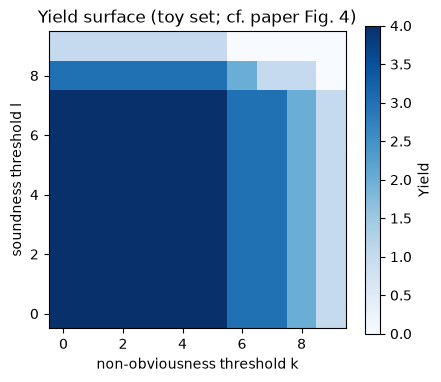

successful-topic ratio at Φ=2 over yields [2,0,3,1]: 0.5 | CST (eq. 7) with $5/topic: 10.0


In [19]:
show_source(X.yield_count)
nb = [7, 8, 6, 9, 5, 8]; s = [7, 7, 8, 7, 9, 8]; c = [6, 7, 6, 6, 6, 7]
pairs = {(0, 1): 8, (0, 2): 3, (0, 3): 7, (0, 4): 9, (0, 5): 7, (1, 2): 9, (1, 3): 2, (1, 4): 9, (1, 5): 1, (2, 3): 7, (2, 4): 9, (2, 5): 8, (3, 4): 9, (3, 5): 7, (4, 5): 9}
y, idx = X.yield_count(nb, s, c, pairs, k=6, l=7, m=6, tau=7)
print(f"toy set of 6 ideas: Yield(NB≥6,S≥7,C≥6,D≥7) = {y}, clique = {idx}  (idea 4 fails NB, ideas 1&5 are near-clones)")
surf = X.yield_surface(nb, s, c, pairs, k_values=range(0, 10), l_values=range(0, 10), m=6, tau=7)
fig, ax = plt.subplots(figsize=(4.8, 4)); im = ax.imshow(surf, origin="lower", cmap="Blues"); plt.colorbar(im, label="Yield")
ax.set(xlabel="non-obviousness threshold k", ylabel="soundness threshold l", title="Yield surface (toy set; cf. paper Fig. 4)"); plt.show()
print("successful-topic ratio at Φ=2 over yields [2,0,3,1]:", X.successful_topics([2, 0, 3, 1], 2), "| CST (eq. 7) with $5/topic:", X.cst([5, 5, 5, 5], [2, 0, 3, 1], 2))

## 12 · Greedy max–min topic selection (Alg. 1) — *not in the repo*

Topic names are embedded, the most isolated topic seeds the set, and the topic least similar to anything already selected is added until the budget Γ is reached. Embeddings via OpenRouter if an embedding model is available, else TF-IDF.

In [20]:
show_source(X.greedy_maxmin_topics)
names = [f"{t.get('topic_name', t['topic_id'])} ({t['domain_id']})" for t in TOPICS]
E = X.openrouter_embed(names)
E = E if E is not None else X.tfidf_embed(names)
sel = X.greedy_maxmin_topics(E, budget=6)
print("Γ=6 selected topics, in order:"); [print("  ", names[i]) for i in sel]
S_ = (E / np.linalg.norm(E, axis=1, keepdims=True)) @ (E / np.linalg.norm(E, axis=1, keepdims=True)).T
print("max pairwise cosine among selected:", round(max(S_[i, j] for a, i in enumerate(sel) for j in sel[a+1:]), 3), "| among all topics:", round(max(S_[i, j] for i in range(len(names)) for j in range(i+1, len(names))), 3))

**greedy_maxmin_topics**

```python
def greedy_maxmin_topics(embeddings: np.ndarray, budget: int) -> list[int]:
    """Greedy max–min selection over cosine similarities (paper Alg. 1).

    Seed = the most isolated topic (lowest mean similarity to the others); then repeatedly add the
    topic whose maximum similarity to the selected set is smallest."""
    E = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
    S = E @ E.T
    n = len(S)
    mean_sim = (S.sum(1) - 1.0) / (n - 1)
    selected = [int(np.argmin(mean_sim))]
    remaining = set(range(n)) - set(selected)
    while len(selected) < min(budget, n):
        i_star = min(remaining, key=lambda i: max(S[i, j] for j in selected))
        selected.append(int(i_star))
        remaining.remove(i_star)
    return selected

```

Γ=6 selected topics, in order:
   Geometry and Linearity of Weight Space (cs.LG)
   End-to-End Autonomous Driving (cs.RO)
   Efficient Attention Mechanisms and KV Cache Optimization (cs.CL)
   Controllable Text-to-Image Synthesis and Editing (cs.CV)
   RL and Search for LLM Reasoning (cs.SE)
   Unifying Diffusion and Flow-Based Generative Models (cs.LG)
max pairwise cosine among selected: 0.369 | among all topics: 1.0


## 13 · Mini end-to-end run vs Stateless baseline, scored with the paper's evaluation protocol

`GenerationLoop.run_topic` is the repo's full controller (Stage I generate → Stage II route/repair → Stage III refine) with a small budget: B free seeds, C_A = 3, K_aux = 1, M soundness samples. The **Stateless** baseline (Sec. 6.2) generates B ideas independently. Both idea sets are then scored the way the paper evaluates (Sec. 5): five 0–9 quality rubrics per idea and eight-axis pairwise distinctness, and Yield is computed at the paper's gate (D ≥ 7, S ≥ 7, C ≥ 6, NB ≥ 6 or 7).

In [21]:
run_dir = OUT / "run" / TOPIC["topic_id"]; run_dir.mkdir(parents=True, exist_ok=True)
t0 = time.time(); calls0 = USAGE.requests
FINAL = loop.run_topic(topic_id=TOPIC["topic_id"], background=BACKGROUND, out_dir=run_dir)
print(f"\nIDEAgent run: {USAGE.requests - calls0} LLM calls, {time.time()-t0:.0f}s")
print("stats:", json.dumps(FINAL.stats(), indent=1)[:1200])
ideagent_ideas = [c.idea_text for c in FINAL.accepted.values()] or [c.idea_text for c in loop.last_lineage_representatives]
print(len(ideagent_ideas), "final ideas; action counts:", FINAL.action_counts)

[g001] free          nb= 45 cl= 55 snd= 57.8 div=100 -> repair_queued    ACTIVE=0 DISC=0 (repair=1)

[g002.r1] repair        nb= 75 cl= 70 snd= 55.6 div=100 -> reject_unsound   ACTIVE=0 DISC=0 (repair=0)

[g003] free          nb= 85 cl= 70 snd= 73.3 div=100 -> accepted         ACTIVE=1 DISC=1 (repair=0)

[g004.r1] accepted_refine nb= 40 cl= 60 snd= 51.1 div=100 -> keep_accepted    ACTIVE=1 DISC=1 (repair=0)

[g005] free          nb= 60 cl= 55 snd= 62.2 div= 82 -> repair_queued    ACTIVE=1 DISC=1 (repair=1)

[g006.r1] repair        nb= 55 cl= 70 snd= 57.8 div= 85 -> reject_unsound   ACTIVE=1 DISC=1 (repair=0)


IDEAgent run: 55 LLM calls, 436s
stats: {
 "free_generations_completed": 3,
 "total_candidates_evaluated": 6,
 "auxiliary_candidates_evaluated": 3,
 "active_yield": 1,
 "discovery_yield": 1,
 "active_actionable_yield": 1,
 "discovery_actionable_yield": 1,
 "feasibility_actionable_min": 60,
 "repair_archive": 0,
 "retired_qualified": 0,
 "historical_qualified": 0,
 "accepted_versions_retained": 1,
 "accepted_parent_child_edges": 0,
 "rejected_pending": 3,
 "has_consolidated_summary": false
}
1 final ideas; action counts: {'free': 3, 'pivot': 0, 'repair': 2, 'novelty_branch': 0, 'accepted_refine': 1}


In [22]:
t0 = time.time(); calls0 = USAGE.requests
stateless_ideas = X.stateless_baseline(BACKGROUND, cfg.max_budget, ic, ikw)
print(f"Stateless baseline: {len(stateless_ideas)} ideas, {USAGE.requests - calls0} calls, {time.time()-t0:.0f}s")

Stateless baseline: 3 ideas, 3 calls, 52s


In [23]:
def score_set(name, ideas):
    q = X.external_quality(ideas, qc, qkw, topic_id=f"{TOPIC['topic_id']}-{name}")
    rep, pairs = X.pairwise_diversity(ideas, jc, jkw, topic_id=f"{TOPIC['topic_id']}-{name}") if len(ideas) > 1 else (None, {})
    nb_ = [q[i].get("nonobviousness", 0) for i in range(len(ideas))]; s_ = [q[i].get("soundness", 0) for i in range(len(ideas))]; c_ = [q[i].get("mechanism_clarity_specificity", 0) for i in range(len(ideas))]
    out = {"method": name, "N": len(ideas), "NB": np.mean(nb_).round(2), "S": np.mean(s_).round(2), "C": np.mean(c_).round(2),
           "F": np.mean([q[i].get("feasibility", 0) for i in q]).round(2), "Sig": np.mean([q[i].get("significance", 0) for i in q]).round(2),
           "pairwise D": (rep.avg_pairwise_score if rep else None)}
    for k in (6, 7):
        out[f"Yield(NB≥{k}, S≥7, C≥6, D≥7)"] = X.yield_count(nb_, s_, c_, pairs, k=k, l=7, m=6, tau=7)[0] if pairs or len(ideas) == 1 else None
    return out, q, pairs
rows = []; detail = {}
for name, ideas in [("IDEAgent", ideagent_ideas), ("Stateless", stateless_ideas)]:
    r, q, pairs = score_set(name, ideas); rows.append(r); detail[name] = (q, pairs)
display(df(rows).set_index("method"))
for name, (q, pairs) in detail.items():
    print(name, "per-idea:", [{m[:5]: v for m, v in q[i].items()} for i in q], "| pairwise D:", pairs)

,N,NB,S,C,F,Sig,pairwise D,"Yield(NB≥6, S≥7, C≥6, D≥7)","Yield(NB≥7, S≥7, C≥6, D≥7)"
method,,,,,,,,,
IDEAgent,1,7.0,3.00,4.00,4.0,6.00,NaN,0,0
Stateless,3,6.0,6.33,5.67,6.0,6.67,4.3333,0,0


IDEAgent per-idea: [{'nonob': 7, 'sound': 3, 'mecha': 4, 'feasi': 4, 'signi': 6}] | pairwise D: {}
Stateless per-idea: [{'nonob': 5, 'sound': 6, 'mecha': 7, 'feasi': 7, 'signi': 6}, {'nonob': 6, 'sound': 6, 'mecha': 6, 'feasi': 5, 'signi': 7}, {'nonob': 7, 'sound': 7, 'mecha': 4, 'feasi': 6, 'signi': 7}] | pairwise D: {(0, 1): 3, (0, 2): 3, (1, 2): 7}


## Summary

| Block | Result of this run |
|---|---|
| Corpus / context | 32 shipped topics; one topic's 5–8 papers rendered into the Ideator context |
| Ideator, Stenographer, Quality, Soundness, Diversity | each called in isolation on the same idea; parsed into the repo's dataclasses |
| Gate G + routing | every Stage II branch reproduced on edited candidates; real candidate routed by `Archive.consider` |
| Q_b + replacement | capacity eviction by weighted quality, displaced idea kept in H |
| Repair, refinement | critic challenge → same-lineage child → re-evaluation; blinded position-swapped NB check |
| Yield / topics | Alg. 2 and Alg. 1 re-implemented; exact max clique from the repo |
| End-to-end vs Stateless | see the table in §13 (single topic, tiny budget — indicative only) |

In [24]:
print(USAGE.summary())

130 requests, 485409 in / 52742 out tokens, 1540s in model calls, $0.0396; by tag: {'critic': 5, 'ideator': 14, 'judge': 17, 'quality+soundness': 82, 'steno': 12}
